In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

import pandas_datareader.data as web
from torch.utils.data import random_split

In [2]:
# Подготовка датасета для обучения в формате inputs, outputs
def make_datasets(input_data, n_inputs=2, n_outputs=1, gap=0):
	L = len(input_data)
	y = np.full((L-n_inputs-n_outputs-gap, n_outputs), 0.0)
	X = np.full((L-n_inputs-n_outputs-gap, n_inputs), 0.0)

	for i in range(n_inputs):
		X[:,i] = input_data[i:L-n_inputs-n_outputs-gap+i]

	for i in range(n_outputs):
		y[:,i] = input_data[n_inputs+gap+i:L-n_outputs+i]

	return X, y

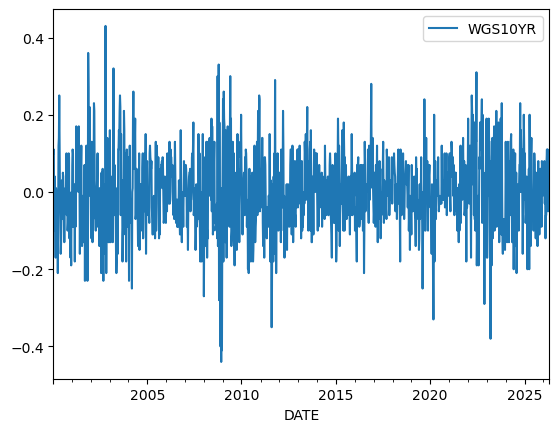

In [3]:
rate = web.DataReader(name='WGS10YR', data_source='fred', start='2000-01-01').diff().dropna()
rate.plot()
plt.show()

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [5]:
# Переведем ряда массив Numpy
series = rate.squeeze().to_numpy()

In [6]:
# задаём ширину окна и горизонт прогнозирования
n_lags, fh= 20, 10

X, y = make_datasets(series, n_inputs=n_lags, n_outputs=fh)

In [7]:
X_tensor = torch.Tensor(X).to(device)
y_tensor = torch.Tensor(y).to(device)

dataset = TensorDataset(X_tensor, y_tensor)

# Для воспроизводимости задаём генератор
generator = torch.Generator().manual_seed(42)
# делим выборку на обучающую и тестовую с соотношении 80:20
train_dataset, test_dataset = random_split(dataset, [0.8, 0.2], generator=generator)

# Создаём DataLoader'ы
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [8]:
# MLP с одним скрытым слоем
hidden_state1 = 25

model1 = nn.Sequential(
    nn.Linear(n_lags, hidden_state1),
    nn.ReLU(),
    # nn.Sigmoid(),
    # nn.Tanh(),
    nn.Linear(hidden_state1, fh)
).to(device)

In [9]:
def train(dataloader, model1, loss_fn, optimizer):
    size = len(dataloader.dataset)

    model1.train()                                 # переводим молель в режим обучения
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()                     # Очищаем старые градиенты
        # Compute prediction error
        y_pred = model1(X)                         # строми прооноз на батче
        loss = loss_fn(y_pred, y)                 # вычисляем ошибку проноза/значение функции потерь

        # Backpropagation
        loss.backward()                           # Вычисляем градиенты
        optimizer.step()                          # Обновляем веса по градиентам

        if batch % 10 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model1, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model1.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model1(X)
            test_loss += loss_fn(pred, y).item()
    
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: Avg loss = {test_loss:>8f} \n")

In [10]:
# Обучение
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model1.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
	print(f"Epoch {epoch+1}\n-------------------------------")
	train(train_dataloader, model1, loss_fn, optimizer)

print("Done!")

Epoch 1
-------------------------------
loss: 0.035537  [   32/ 1075]
loss: 0.028683  [  352/ 1075]
loss: 0.022351  [  672/ 1075]
loss: 0.017461  [  992/ 1075]
Epoch 2
-------------------------------
loss: 0.018268  [   32/ 1075]
loss: 0.013610  [  352/ 1075]
loss: 0.012631  [  672/ 1075]
loss: 0.012651  [  992/ 1075]
Epoch 3
-------------------------------
loss: 0.011211  [   32/ 1075]
loss: 0.010443  [  352/ 1075]
loss: 0.011516  [  672/ 1075]
loss: 0.010145  [  992/ 1075]
Epoch 4
-------------------------------
loss: 0.008165  [   32/ 1075]
loss: 0.010101  [  352/ 1075]
loss: 0.012493  [  672/ 1075]
loss: 0.008851  [  992/ 1075]
Epoch 5
-------------------------------
loss: 0.007862  [   32/ 1075]
loss: 0.010118  [  352/ 1075]
loss: 0.009043  [  672/ 1075]
loss: 0.008875  [  992/ 1075]
Epoch 6
-------------------------------
loss: 0.009777  [   32/ 1075]
loss: 0.012097  [  352/ 1075]
loss: 0.008406  [  672/ 1075]
loss: 0.009509  [  992/ 1075]
Epoch 7
-------------------------------


In [11]:
# метрики на тестово множества
test(test_dataloader, model1, loss_fn)

Test Error: Avg loss = 0.011384 



In [12]:
# MLP с одним скрытым слоем
hidden_state2 = 30

model2 = nn.Sequential(
    nn.Linear(n_lags, hidden_state2),
    nn.ReLU(),
    # nn.Sigmoid(),
    # nn.Tanh(),
    nn.Linear(hidden_state2, fh)
).to(device)

In [13]:
def train(dataloader, model2, loss_fn, optimizer):
    size = len(dataloader.dataset)

    model2.train()                                 # переводим молель в режим обучения
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()                     # Очищаем старые градиенты
        # Compute prediction error
        y_pred = model2(X)                         # строми прооноз на батче
        loss = loss_fn(y_pred, y)                 # вычисляем ошибку проноза/значение функции потерь

        # Backpropagation
        loss.backward()                           # Вычисляем градиенты
        optimizer.step()                          # Обновляем веса по градиентам

        if batch % 10 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model2, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model2.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model2(X)
            test_loss += loss_fn(pred, y).item()
    
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: Avg loss = {test_loss:>8f} \n")

In [14]:
# Обучение
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model2.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
	print(f"Epoch {epoch+1}\n-------------------------------")
	train(train_dataloader, model2, loss_fn, optimizer)

print("Done!")

Epoch 1
-------------------------------
loss: 0.025723  [   32/ 1075]
loss: 0.026126  [  352/ 1075]
loss: 0.017956  [  672/ 1075]
loss: 0.016288  [  992/ 1075]
Epoch 2
-------------------------------
loss: 0.014653  [   32/ 1075]
loss: 0.010815  [  352/ 1075]
loss: 0.010680  [  672/ 1075]
loss: 0.010557  [  992/ 1075]
Epoch 3
-------------------------------
loss: 0.011362  [   32/ 1075]
loss: 0.010204  [  352/ 1075]
loss: 0.010727  [  672/ 1075]
loss: 0.009432  [  992/ 1075]
Epoch 4
-------------------------------
loss: 0.009612  [   32/ 1075]
loss: 0.011626  [  352/ 1075]
loss: 0.011587  [  672/ 1075]
loss: 0.008877  [  992/ 1075]
Epoch 5
-------------------------------
loss: 0.010693  [   32/ 1075]
loss: 0.010278  [  352/ 1075]
loss: 0.007884  [  672/ 1075]
loss: 0.010698  [  992/ 1075]
Epoch 6
-------------------------------
loss: 0.008625  [   32/ 1075]
loss: 0.012531  [  352/ 1075]
loss: 0.008421  [  672/ 1075]
loss: 0.007218  [  992/ 1075]
Epoch 7
-------------------------------


In [15]:
# метрики на тестово множества
test(test_dataloader, model2, loss_fn)

Test Error: Avg loss = 0.011305 



In [16]:
# MLP с одним скрытым слоем
hidden_state3 = 35

model3 = nn.Sequential(
    nn.Linear(n_lags, hidden_state3),
    nn.ReLU(),
    # nn.Sigmoid(),
    # nn.Tanh(),
    nn.Linear(hidden_state3, fh)
).to(device)

In [17]:
def train(dataloader, model3, loss_fn, optimizer):
    size = len(dataloader.dataset)

    model3.train()                                 # переводим молель в режим обучения
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()                     # Очищаем старые градиенты
        # Compute prediction error
        y_pred = model3(X)                         # строми прооноз на батче
        loss = loss_fn(y_pred, y)                 # вычисляем ошибку проноза/значение функции потерь

        # Backpropagation
        loss.backward()                           # Вычисляем градиенты
        optimizer.step()                          # Обновляем веса по градиентам

        if batch % 10 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model3, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model3.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model3(X)
            test_loss += loss_fn(pred, y).item()
    
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: Avg loss = {test_loss:>8f} \n")

In [18]:
# Обучение
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model3.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
	print(f"Epoch {epoch+1}\n-------------------------------")
	train(train_dataloader, model3, loss_fn, optimizer)

print("Done!")

Epoch 1
-------------------------------
loss: 0.020088  [   32/ 1075]
loss: 0.016227  [  352/ 1075]
loss: 0.012313  [  672/ 1075]
loss: 0.011495  [  992/ 1075]
Epoch 2
-------------------------------
loss: 0.009716  [   32/ 1075]
loss: 0.009926  [  352/ 1075]
loss: 0.009993  [  672/ 1075]
loss: 0.011687  [  992/ 1075]
Epoch 3
-------------------------------
loss: 0.008374  [   32/ 1075]
loss: 0.011380  [  352/ 1075]
loss: 0.009379  [  672/ 1075]
loss: 0.010419  [  992/ 1075]
Epoch 4
-------------------------------
loss: 0.009385  [   32/ 1075]
loss: 0.008611  [  352/ 1075]
loss: 0.009412  [  672/ 1075]
loss: 0.012187  [  992/ 1075]
Epoch 5
-------------------------------
loss: 0.010128  [   32/ 1075]
loss: 0.010083  [  352/ 1075]
loss: 0.011049  [  672/ 1075]
loss: 0.008524  [  992/ 1075]
Epoch 6
-------------------------------
loss: 0.010717  [   32/ 1075]
loss: 0.007844  [  352/ 1075]
loss: 0.011491  [  672/ 1075]
loss: 0.009955  [  992/ 1075]
Epoch 7
-------------------------------


In [19]:
# метрики на тестово множества
test(test_dataloader, model3, loss_fn)

Test Error: Avg loss = 0.011442 



In [20]:
# MLP с одним скрытым слоем
hidden_state4 = 40

model4 = nn.Sequential(
    nn.Linear(n_lags, hidden_state4),
    nn.ReLU(),
    # nn.Sigmoid(),
    # nn.Tanh(),
    nn.Linear(hidden_state4, fh)
).to(device)

In [21]:
def train(dataloader, model4, loss_fn, optimizer):
    size = len(dataloader.dataset)

    model4.train()                                 # переводим молель в режим обучения
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()                     # Очищаем старые градиенты
        # Compute prediction error
        y_pred = model4(X)                         # строми прооноз на батче
        loss = loss_fn(y_pred, y)                 # вычисляем ошибку проноза/значение функции потерь

        # Backpropagation
        loss.backward()                           # Вычисляем градиенты
        optimizer.step()                          # Обновляем веса по градиентам

        if batch % 10 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model4, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model4.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model4(X)
            test_loss += loss_fn(pred, y).item()
    
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: Avg loss = {test_loss:>8f} \n")

In [22]:
# Обучение
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model4.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
	print(f"Epoch {epoch+1}\n-------------------------------")
	train(train_dataloader, model4, loss_fn, optimizer)

print("Done!")

Epoch 1
-------------------------------
loss: 0.015924  [   32/ 1075]
loss: 0.013780  [  352/ 1075]
loss: 0.012258  [  672/ 1075]
loss: 0.009736  [  992/ 1075]
Epoch 2
-------------------------------
loss: 0.011985  [   32/ 1075]
loss: 0.013133  [  352/ 1075]
loss: 0.013328  [  672/ 1075]
loss: 0.011887  [  992/ 1075]
Epoch 3
-------------------------------
loss: 0.009918  [   32/ 1075]
loss: 0.008133  [  352/ 1075]
loss: 0.010158  [  672/ 1075]
loss: 0.009925  [  992/ 1075]
Epoch 4
-------------------------------
loss: 0.009792  [   32/ 1075]
loss: 0.011089  [  352/ 1075]
loss: 0.009056  [  672/ 1075]
loss: 0.008204  [  992/ 1075]
Epoch 5
-------------------------------
loss: 0.010086  [   32/ 1075]
loss: 0.010317  [  352/ 1075]
loss: 0.007819  [  672/ 1075]
loss: 0.008576  [  992/ 1075]
Epoch 6
-------------------------------
loss: 0.011222  [   32/ 1075]
loss: 0.010376  [  352/ 1075]
loss: 0.011076  [  672/ 1075]
loss: 0.009996  [  992/ 1075]
Epoch 7
-------------------------------


In [23]:
# метрики на тестово множества
test(test_dataloader, model4, loss_fn)

Test Error: Avg loss = 0.011324 



Лучшее число состояний - 25

In [24]:
# MLP с одним скрытым слоем
hidden_state1 = 25

model1_s = nn.Sequential(
    nn.Linear(n_lags, hidden_state1),
    # nn.ReLU(),
    nn.Sigmoid(),
    # nn.Tanh(),
    nn.Linear(hidden_state1, fh)
).to(device)

In [25]:
def train(dataloader, model1_s, loss_fn, optimizer):
    size = len(dataloader.dataset)

    model1_s.train()                                 # переводим молель в режим обучения
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()                     # Очищаем старые градиенты
        # Compute prediction error
        y_pred = model1_s(X)                         # строми прооноз на батче
        loss = loss_fn(y_pred, y)                 # вычисляем ошибку проноза/значение функции потерь

        # Backpropagation
        loss.backward()                           # Вычисляем градиенты
        optimizer.step()                          # Обновляем веса по градиентам

        if batch % 10 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model1_s, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model1_s.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model1_s(X)
            test_loss += loss_fn(pred, y).item()
    
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: Avg loss = {test_loss:>8f} \n")

In [26]:
# Обучение
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model1_s.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
	print(f"Epoch {epoch+1}\n-------------------------------")
	train(train_dataloader, model1_s, loss_fn, optimizer)

print("Done!")

Epoch 1
-------------------------------
loss: 0.199240  [   32/ 1075]
loss: 0.125256  [  352/ 1075]
loss: 0.078968  [  672/ 1075]
loss: 0.054405  [  992/ 1075]
Epoch 2
-------------------------------
loss: 0.044714  [   32/ 1075]
loss: 0.028093  [  352/ 1075]
loss: 0.019516  [  672/ 1075]
loss: 0.017436  [  992/ 1075]
Epoch 3
-------------------------------
loss: 0.013292  [   32/ 1075]
loss: 0.012395  [  352/ 1075]
loss: 0.010058  [  672/ 1075]
loss: 0.008558  [  992/ 1075]
Epoch 4
-------------------------------
loss: 0.011374  [   32/ 1075]
loss: 0.010728  [  352/ 1075]
loss: 0.009473  [  672/ 1075]
loss: 0.010908  [  992/ 1075]
Epoch 5
-------------------------------
loss: 0.010493  [   32/ 1075]
loss: 0.008883  [  352/ 1075]
loss: 0.010618  [  672/ 1075]
loss: 0.008777  [  992/ 1075]
Epoch 6
-------------------------------
loss: 0.011688  [   32/ 1075]
loss: 0.011065  [  352/ 1075]
loss: 0.010119  [  672/ 1075]
loss: 0.010883  [  992/ 1075]
Epoch 7
-------------------------------


In [27]:
# метрики на тестово множества
test(test_dataloader, model1_s, loss_fn)

Test Error: Avg loss = 0.011294 



In [28]:
model1_t = nn.Sequential(
    nn.Linear(n_lags, hidden_state1),
    # nn.ReLU(),
    # nn.Sigmoid(),
    nn.Tanh(),
    nn.Linear(hidden_state1, fh)
).to(device)

In [29]:
def train(dataloader, model1_t, loss_fn, optimizer):
    size = len(dataloader.dataset)

    model1_t.train()                                 # переводим молель в режим обучения
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()                     # Очищаем старые градиенты
        # Compute prediction error
        y_pred = model1_t(X)                         # строми прооноз на батче
        loss = loss_fn(y_pred, y)                 # вычисляем ошибку проноза/значение функции потерь

        # Backpropagation
        loss.backward()                           # Вычисляем градиенты
        optimizer.step()                          # Обновляем веса по градиентам

        if batch % 10 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model1_t, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model1_t.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model1_t(X)
            test_loss += loss_fn(pred, y).item()
    
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: Avg loss = {test_loss:>8f} \n")

In [30]:
# Обучение
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model1_t.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
	print(f"Epoch {epoch+1}\n-------------------------------")
	train(train_dataloader, model1_t, loss_fn, optimizer)

print("Done!")

Epoch 1
-------------------------------
loss: 0.031514  [   32/ 1075]
loss: 0.021640  [  352/ 1075]
loss: 0.013551  [  672/ 1075]
loss: 0.014468  [  992/ 1075]
Epoch 2
-------------------------------
loss: 0.010742  [   32/ 1075]
loss: 0.012564  [  352/ 1075]
loss: 0.012094  [  672/ 1075]
loss: 0.010339  [  992/ 1075]
Epoch 3
-------------------------------
loss: 0.012944  [   32/ 1075]
loss: 0.011044  [  352/ 1075]
loss: 0.007205  [  672/ 1075]
loss: 0.012535  [  992/ 1075]
Epoch 4
-------------------------------
loss: 0.009296  [   32/ 1075]
loss: 0.010371  [  352/ 1075]
loss: 0.009033  [  672/ 1075]
loss: 0.011054  [  992/ 1075]
Epoch 5
-------------------------------
loss: 0.009587  [   32/ 1075]
loss: 0.010970  [  352/ 1075]
loss: 0.010580  [  672/ 1075]
loss: 0.010576  [  992/ 1075]
Epoch 6
-------------------------------
loss: 0.010312  [   32/ 1075]
loss: 0.009075  [  352/ 1075]
loss: 0.008195  [  672/ 1075]
loss: 0.010242  [  992/ 1075]
Epoch 7
-------------------------------


In [31]:
# метрики на тестово множества
test(test_dataloader, model1_t, loss_fn)

Test Error: Avg loss = 0.011390 



In [32]:
# MLP с одним скрытым слоем
hidden_state4 = 40

model4_s = nn.Sequential(
    nn.Linear(n_lags, hidden_state4),
    # nn.ReLU(),
    nn.Sigmoid(),
    # nn.Tanh(),
    nn.Linear(hidden_state4, fh)
).to(device)

In [33]:
def train(dataloader, model4_s, loss_fn, optimizer):
    size = len(dataloader.dataset)

    model4_s.train()                                 # переводим молель в режим обучения
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()                     # Очищаем старые градиенты
        # Compute prediction error
        y_pred = model4_s(X)                         # строми прооноз на батче
        loss = loss_fn(y_pred, y)                 # вычисляем ошибку проноза/значение функции потерь

        # Backpropagation
        loss.backward()                           # Вычисляем градиенты
        optimizer.step()                          # Обновляем веса по градиентам

        if batch % 10 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model4_s, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model4_s.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model4_s(X)
            test_loss += loss_fn(pred, y).item()
    
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: Avg loss = {test_loss:>8f} \n")

In [34]:
# Обучение
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model4_s.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
	print(f"Epoch {epoch+1}\n-------------------------------")
	train(train_dataloader, model4_s, loss_fn, optimizer)

print("Done!")

Epoch 1
-------------------------------
loss: 0.107941  [   32/ 1075]
loss: 0.033505  [  352/ 1075]
loss: 0.012355  [  672/ 1075]
loss: 0.012024  [  992/ 1075]
Epoch 2
-------------------------------
loss: 0.011050  [   32/ 1075]
loss: 0.011957  [  352/ 1075]
loss: 0.009799  [  672/ 1075]
loss: 0.008047  [  992/ 1075]
Epoch 3
-------------------------------
loss: 0.008363  [   32/ 1075]
loss: 0.009182  [  352/ 1075]
loss: 0.009189  [  672/ 1075]
loss: 0.010901  [  992/ 1075]
Epoch 4
-------------------------------
loss: 0.009593  [   32/ 1075]
loss: 0.010034  [  352/ 1075]
loss: 0.010700  [  672/ 1075]
loss: 0.009755  [  992/ 1075]
Epoch 5
-------------------------------
loss: 0.008889  [   32/ 1075]
loss: 0.009614  [  352/ 1075]
loss: 0.007689  [  672/ 1075]
loss: 0.011810  [  992/ 1075]
Epoch 6
-------------------------------
loss: 0.008254  [   32/ 1075]
loss: 0.009512  [  352/ 1075]
loss: 0.006577  [  672/ 1075]
loss: 0.009365  [  992/ 1075]
Epoch 7
-------------------------------


In [35]:
# метрики на тестово множества
test(test_dataloader, model4_s, loss_fn)

Test Error: Avg loss = 0.011324 



In [36]:
model4_t = nn.Sequential(
    nn.Linear(n_lags, hidden_state4),
    # nn.ReLU(),
    # nn.Sigmoid(),
    nn.Tanh(),
    nn.Linear(hidden_state4, fh)
).to(device)

In [37]:
def train(dataloader, model4_t, loss_fn, optimizer):
    size = len(dataloader.dataset)

    model4_t.train()                                 # переводим молель в режим обучения
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()                     # Очищаем старые градиенты
        # Compute prediction error
        y_pred = model4_t(X)                         # строми прооноз на батче
        loss = loss_fn(y_pred, y)                 # вычисляем ошибку проноза/значение функции потерь

        # Backpropagation
        loss.backward()                           # Вычисляем градиенты
        optimizer.step()                          # Обновляем веса по градиентам

        if batch % 10 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model4_t, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model4_t.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model4_t(X)
            test_loss += loss_fn(pred, y).item()
    
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: Avg loss = {test_loss:>8f} \n")

In [38]:
# Обучение
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model4_t.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
	print(f"Epoch {epoch+1}\n-------------------------------")
	train(train_dataloader, model4_t, loss_fn, optimizer)

print("Done!")

Epoch 1
-------------------------------
loss: 0.036372  [   32/ 1075]
loss: 0.019428  [  352/ 1075]
loss: 0.013041  [  672/ 1075]
loss: 0.012671  [  992/ 1075]
Epoch 2
-------------------------------
loss: 0.011032  [   32/ 1075]
loss: 0.013567  [  352/ 1075]
loss: 0.009648  [  672/ 1075]
loss: 0.012951  [  992/ 1075]
Epoch 3
-------------------------------
loss: 0.011283  [   32/ 1075]
loss: 0.012643  [  352/ 1075]
loss: 0.007277  [  672/ 1075]
loss: 0.009513  [  992/ 1075]
Epoch 4
-------------------------------
loss: 0.008834  [   32/ 1075]
loss: 0.008437  [  352/ 1075]
loss: 0.007554  [  672/ 1075]
loss: 0.008382  [  992/ 1075]
Epoch 5
-------------------------------
loss: 0.011263  [   32/ 1075]
loss: 0.007686  [  352/ 1075]
loss: 0.009267  [  672/ 1075]
loss: 0.010348  [  992/ 1075]
Epoch 6
-------------------------------
loss: 0.010329  [   32/ 1075]
loss: 0.008909  [  352/ 1075]
loss: 0.009351  [  672/ 1075]
loss: 0.006864  [  992/ 1075]
Epoch 7
-------------------------------


In [39]:
# метрики на тестово множества
test(test_dataloader, model4_t, loss_fn)

Test Error: Avg loss = 0.011399 



1. 25 ReLu оптимизирует лучше всех
2. 40 Sigmoid